In [1]:
from src.utils.config import DATASET_FINALV2, RAW_DIR

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import librosa
import librosa.display

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import umap

from tqdm import tqdm
import torch.nn as nn
from matplotlib.animation import FuncAnimation
from sklearn.utils import resample

/home/andres/Documentos/proyecto4geeks/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sns.set_theme(style="whitegrid")
def pastel_colors(n):
    return sns.color_palette("pastel", n)

plt.rcParams["figure.figsize"] = (12,6)

In [3]:
data = pd.read_csv(DATASET_FINALV2)

In [4]:
print("Total audios:", len(data))

Total audios: 132384


In [5]:
eda = data.copy()

In [6]:
eda.shape

(132384, 20)

In [7]:
eda.head()

,audio,label,labels,human_label,human_labels,path,dataset_source,split,env,alertable,emergency,file_exists,audio_format,duration,sample_rate,channels,bit_depth,bit_velocity,size,date_modification
0,--PJHxphWEs.wav,/C/gun_shot_2778111f,"[""/C/gun_shot_2778111f""]",gun_shot,"[""gun_shot""]",/home/andres/Documentos/proyecto4geeks/data/ra...,sonidos,train,NaN,True,True,True,wav,10.008,44100.0,Stereo,16.0,1411200.0,1724.11,2026-05-12 17:56:50
1,--aE2O5G5WE.wav,/C/gun_shot_2778111f,"[""/C/gun_shot_2778111f""]",gun_shot,"[""gun_shot""]",/home/andres/Documentos/proyecto4geeks/data/ra...,sonidos,train,NaN,True,True,True,wav,10.008,44100.0,Stereo,16.0,1411200.0,1724.08,2026-05-12 12:27:49
2,-0DLPzsiXXE.wav,/C/human_activity_6f5e2785,"[""/C/human_activity_6f5e2785""]",human_activity,"[""human_activity""]",/home/andres/Documentos/proyecto4geeks/data/ra...,sonidos,train,NaN,False,False,True,wav,19.994,48000.0,Stereo,16.0,1536000.0,3748.86,2026-05-12 17:57:08
3,-0SdAVK79lg.wav,/C/human_activity_6f5e2785,"[""/C/human_activity_6f5e2785""]",human_activity,"[""human_activity""]",/home/andres/Documentos/proyecto4geeks/data/ra...,sonidos,train,NaN,False,False,True,wav,19.994,48000.0,Stereo,16.0,1536000.0,3748.86,2026-05-12 12:36:58
4,-11LhdJgBb8.wav,/C/human_activity_6f5e2785,"[""/C/human_activity_6f5e2785""]",human_activity,"[""human_activity""]",/home/andres/Documentos/proyecto4geeks/data/ra...,sonidos,test,NaN,False,False,True,wav,19.994,48000.0,Stereo,16.0,1536000.0,3748.86,2026-05-12 17:57:22


In [8]:
eda.info()

<class 'pandas.DataFrame'>
RangeIndex: 132384 entries, 0 to 132383
Data columns (total 20 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   audio              132384 non-null  str    
 1   label              132384 non-null  str    
 2   labels             75566 non-null   str    
 3   human_label        132384 non-null  str    
 4   human_labels       75566 non-null   str    
 5   path               132384 non-null  str    
 6   dataset_source     132384 non-null  str    
 7   split              132384 non-null  str    
 8   env                9039 non-null    str    
 9   alertable          132384 non-null  bool   
 10  emergency          132384 non-null  bool   
 11  file_exists        132384 non-null  bool   
 12  audio_format       132379 non-null  str    
 13  duration           132379 non-null  float64
 14  sample_rate        132379 non-null  float64
 15  channels           132379 non-null  str    
 16  bit_depth    

In [9]:
eda.describe(include="all")

,audio,label,labels,human_label,human_labels,path,dataset_source,split,env,alertable,emergency,file_exists,audio_format,duration,sample_rate,channels,bit_depth,bit_velocity,size,date_modification
count,132384,132384,75566,132384,75566,132384,132384,132384,9039,132384,132384,132384,132379,132379.000000,132379.000000,132379,132370.000000,1.323700e+05,132379.000000,132379
unique,132277,213,3269,26,1159,132384,11,2,2,2,2,1,2,NaN,NaN,3,NaN,NaN,NaN,1496
top,-4RWqM0UCCY.wav,/m/0k5j,"[""/C/gun_shot_2778111f""]",traffic,"[""instrument"", ""human_activity""]",/home/andres/Documentos/proyecto4geeks/data/ra...,zenodo,train,exterior,True,False,True,wav,NaN,NaN,Mono,NaN,NaN,NaN,2026-05-20 00:32:09
freq,2,14749,5384,17581,14187,1,51197,109802,5329,67122,101512,132384,129625,NaN,NaN,123041,NaN,NaN,NaN,887
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.852201,34012.803337,NaN,22.224734,7.240811e+05,430.887647,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.947076,14432.114529,NaN,7.718821,4.168731e+05,671.946820,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.025000,8000.000000,NaN,8.000000,8.820000e+04,1.610000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.294000,16000.000000,NaN,16.000000,5.120000e+05,98.270000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.061000,44100.000000,NaN,16.000000,7.056000e+05,227.030000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.761000,44100.000000,NaN,32.000000,7.056000e+05,542.620000,NaN


<Axes: xlabel='dataset_source'>

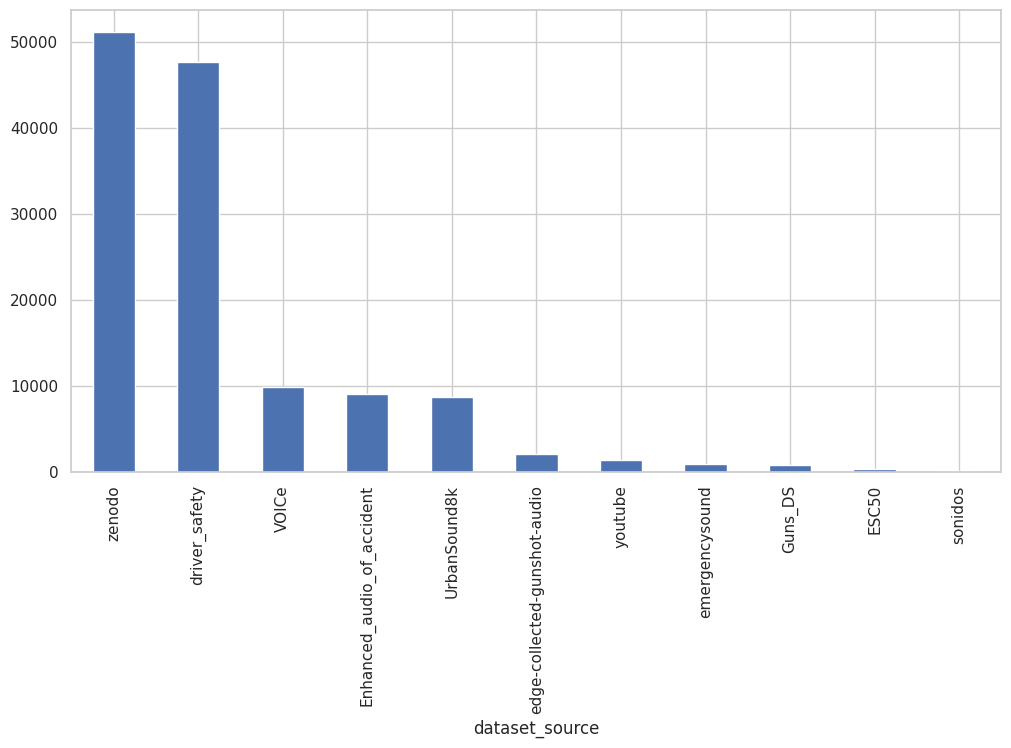

In [10]:
eda["dataset_source"].value_counts().plot(kind="bar")

El dataset final corresponde a una integración multifuente de datos acústicos provenientes de diferentes repositorios públicos.

Se identifican diferencias estructurales entre datasets en cuanto a metadata disponible, duración de audio y esquema de etiquetado, lo cual introduce heterogeneidad que debe considerarse durante el modelado.

In [11]:
eda.isna().sum().sort_values(ascending=False)

env                  123345
labels                56818
human_labels          56818
bit_depth                14
bit_velocity             14
size                      5
sample_rate               5
date_modification         5
duration                  5
audio_format              5
channels                  5
audio                     0
human_label               0
label                     0
file_exists               0
emergency                 0
path                      0
dataset_source            0
alertable                 0
split                     0
dtype: int64

<Axes: >

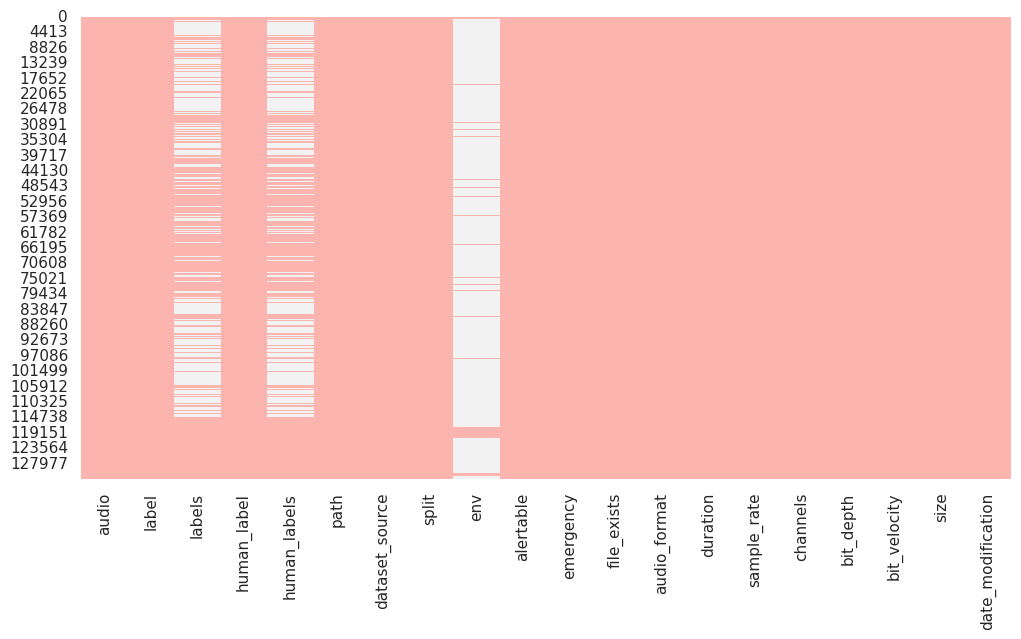

In [12]:
sns.heatmap(eda.isna(), cmap="Pastel1", cbar=False)

Se observa presencia de valores faltantes principalmente en variables de anotación humana, indicando diferencias en el proceso de etiquetado entre datasets origen. Las variables técnicas del audio presentan mayor completitud, permitiendo análisis acústicos consistentes.

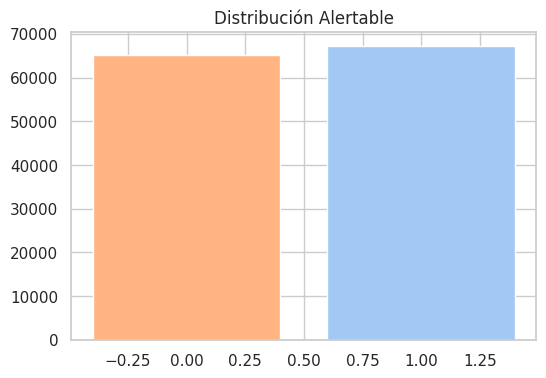

In [13]:
counts = eda["alertable"].value_counts()

plt.figure(figsize=(6,4))

plt.bar(
    counts.index,
    counts.values,
    color=pastel_colors(len(counts))
)

plt.title("Distribución Alertable")
plt.show()

La variable objetivo alertable permite reformular el problema como una tarea de clasificación funcional basada en relevancia operativa del sonido, reduciendo el sesgo generado por clases extremadamente desbalanceadas presentes en la etiqueta emergency.

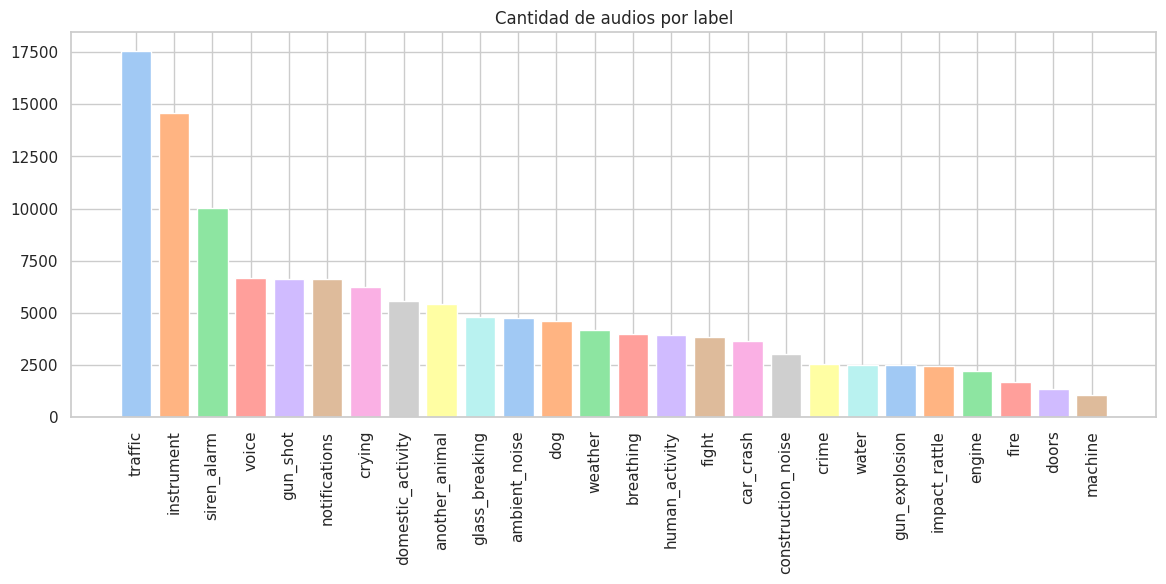

In [14]:
label_counts = eda["human_label"].value_counts()

plt.figure(figsize=(14,5))

plt.bar(
    label_counts.index,
    label_counts.values,
    color=pastel_colors(len(label_counts))
)

plt.xticks(rotation=90)
plt.title("Cantidad de audios por label")

plt.show()

In [15]:
eda.groupby("human_label")["alertable"].mean()

human_label
ambient_noise         0.0
another_animal        0.0
breathing             0.0
car_crash             1.0
construction_noise    1.0
crime                 1.0
crying                1.0
dog                   1.0
domestic_activity     0.0
doors                 0.0
engine                0.0
fight                 1.0
fire                  1.0
glass_breaking        1.0
gun_explosion         1.0
gun_shot              1.0
human_activity        0.0
impact_rattle         0.0
instrument            0.0
machine               0.0
notifications         0.0
siren_alarm           1.0
traffic               1.0
voice                 0.0
water                 0.0
weather               0.0
Name: alertable, dtype: float64

Se evidencia desbalance severo entre clases acústicas, lo cual puede inducir sesgo hacia clases dominantes. Será necesario aplicar técnicas como:

- class weighting
- focal loss
- oversampling

/tmp/ipykernel_82102/588572439.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = eda.select_dtypes(include="object").columns


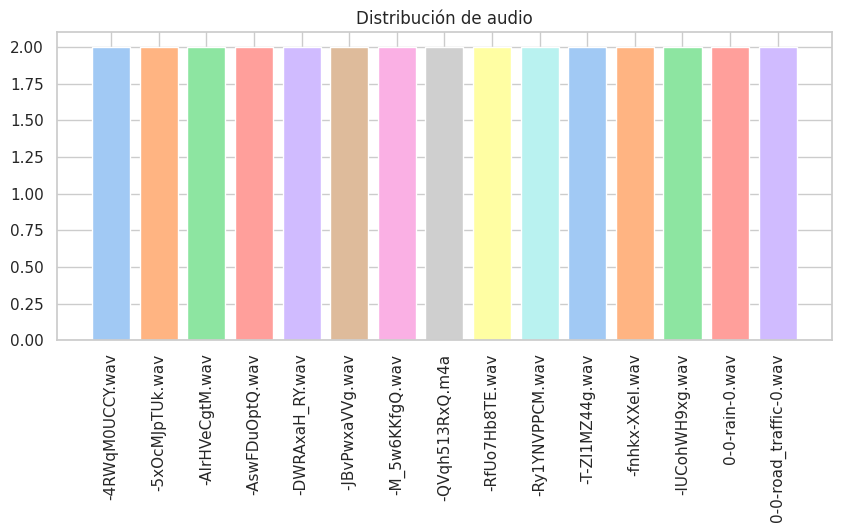

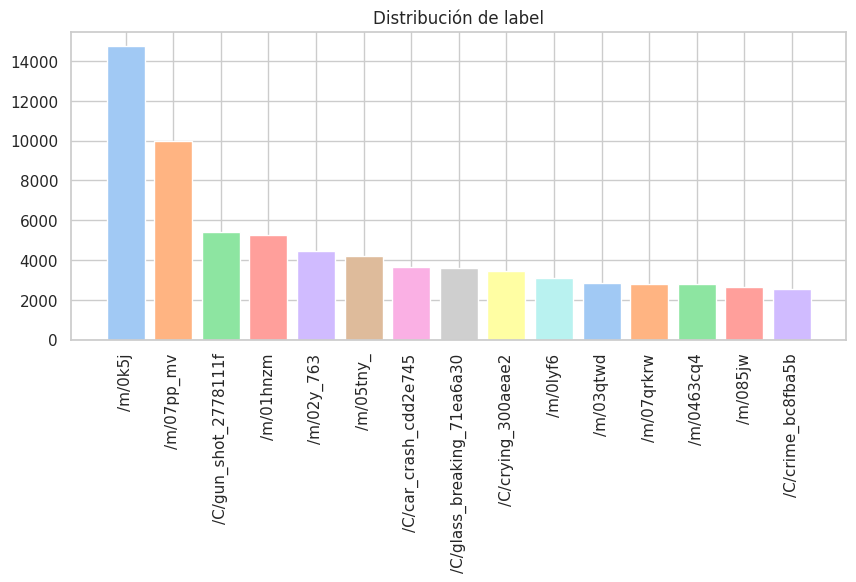

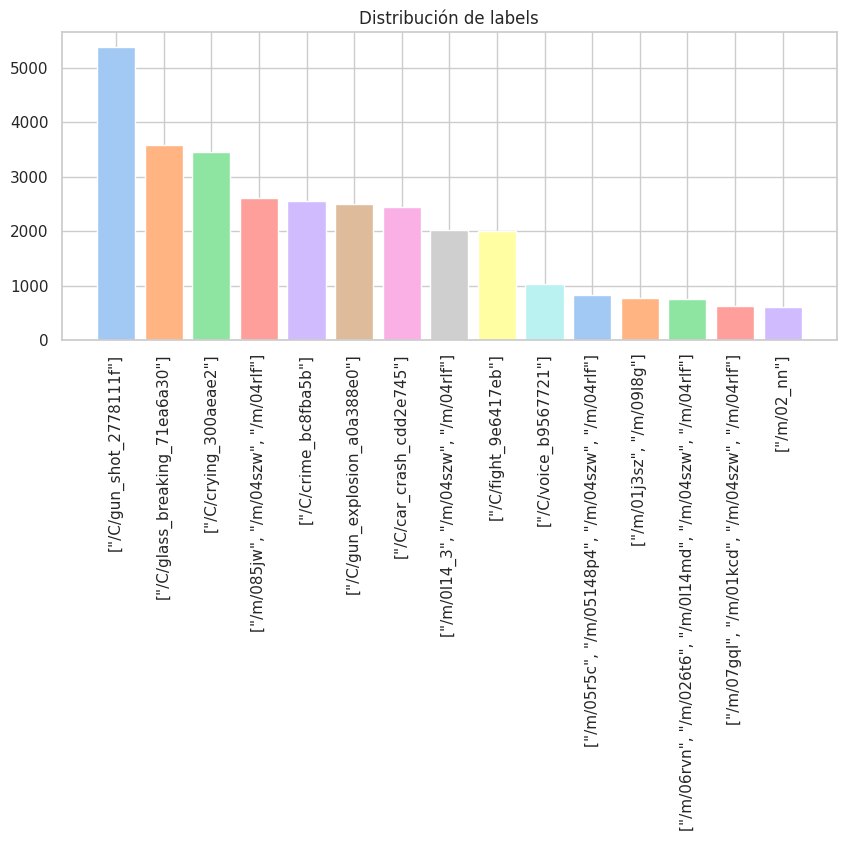

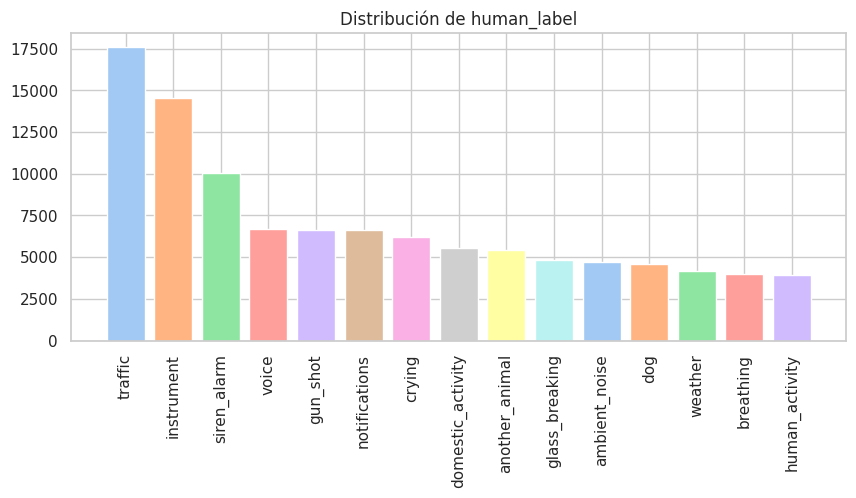

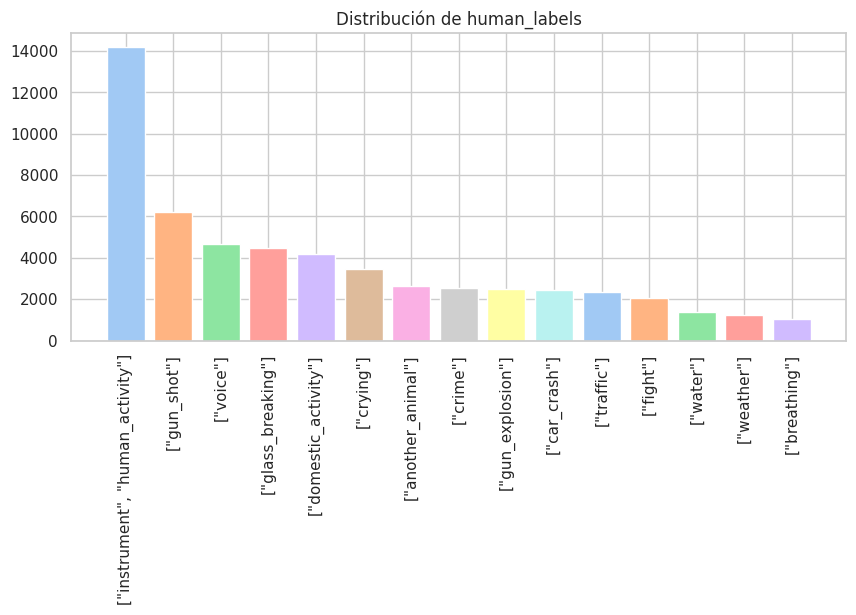

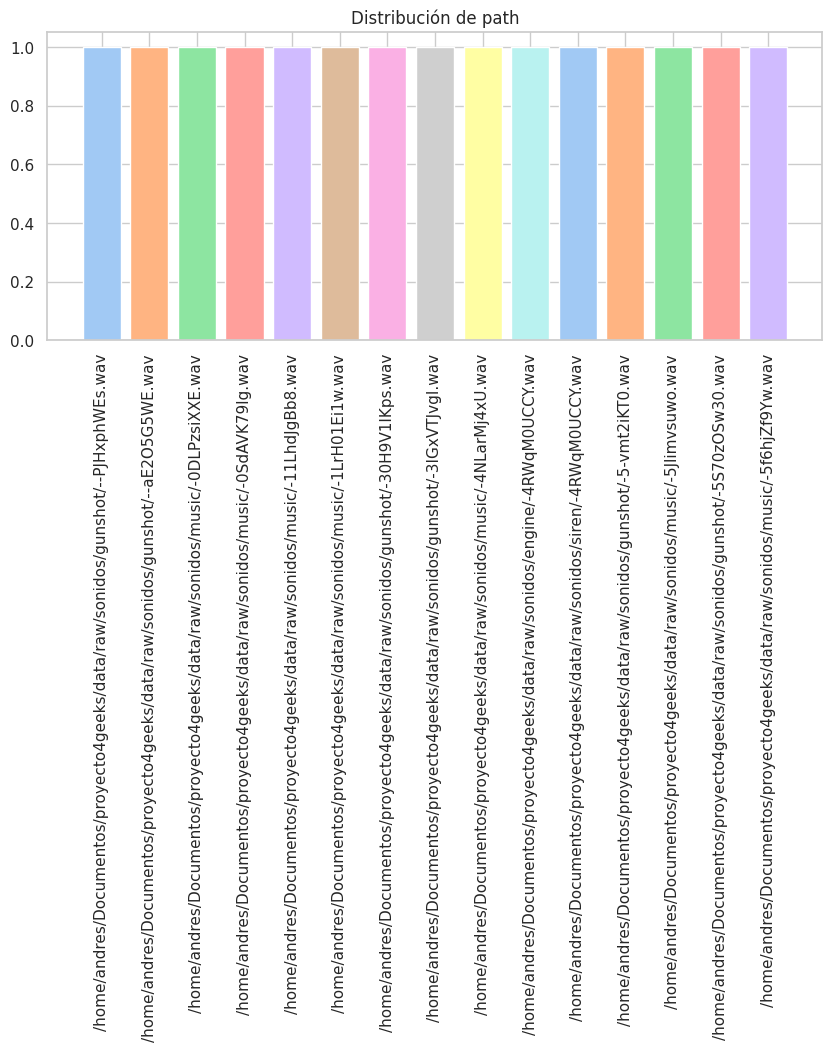

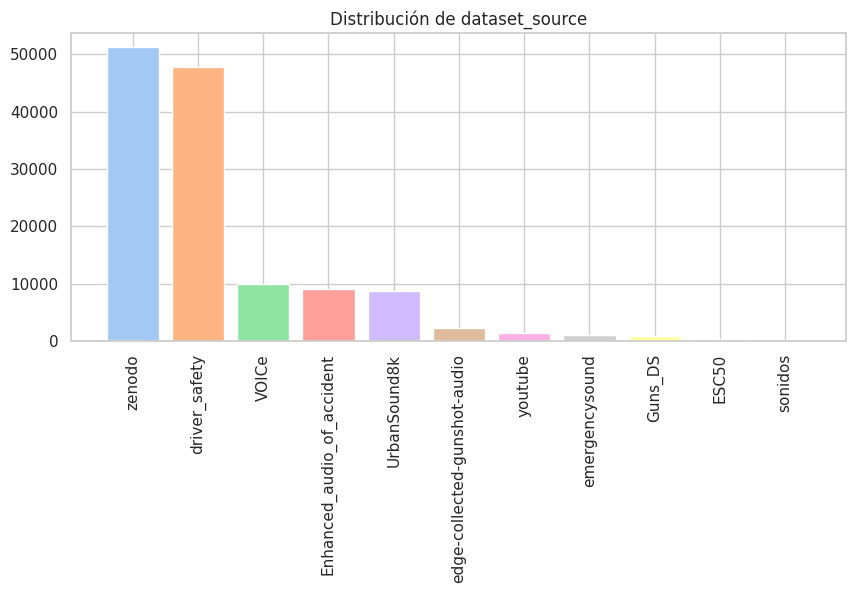

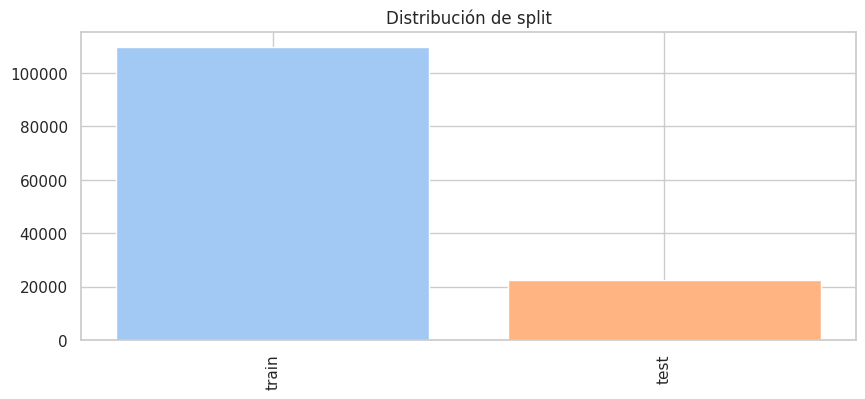

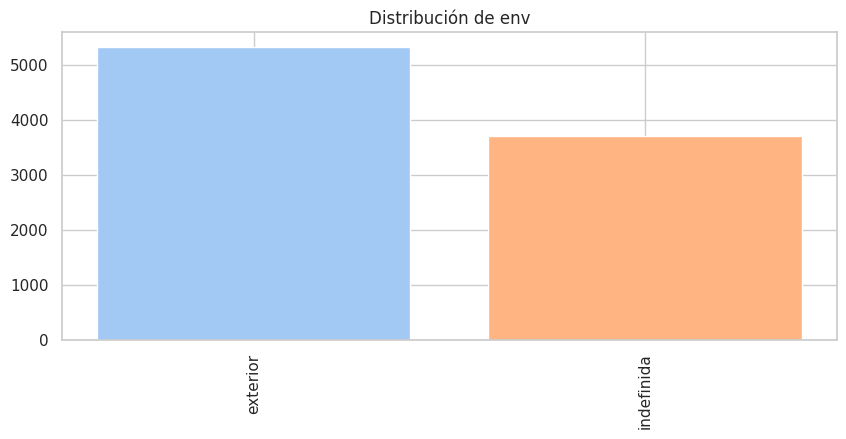

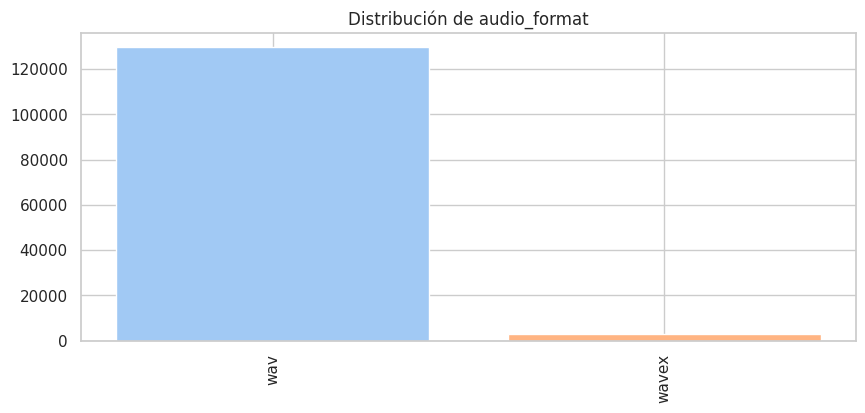

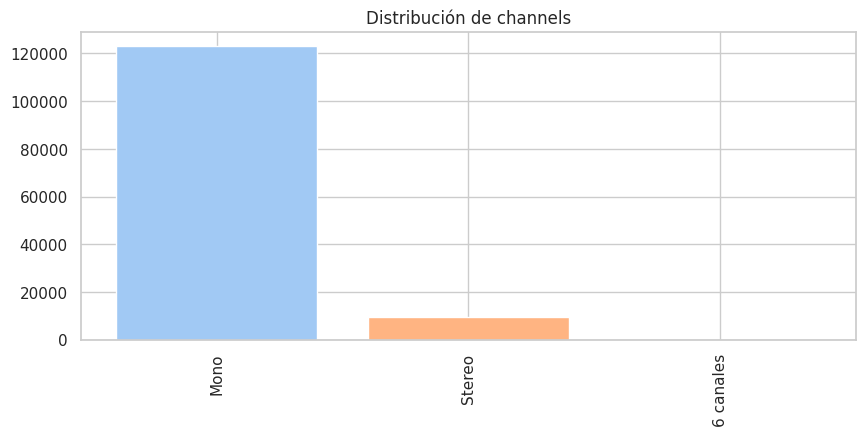

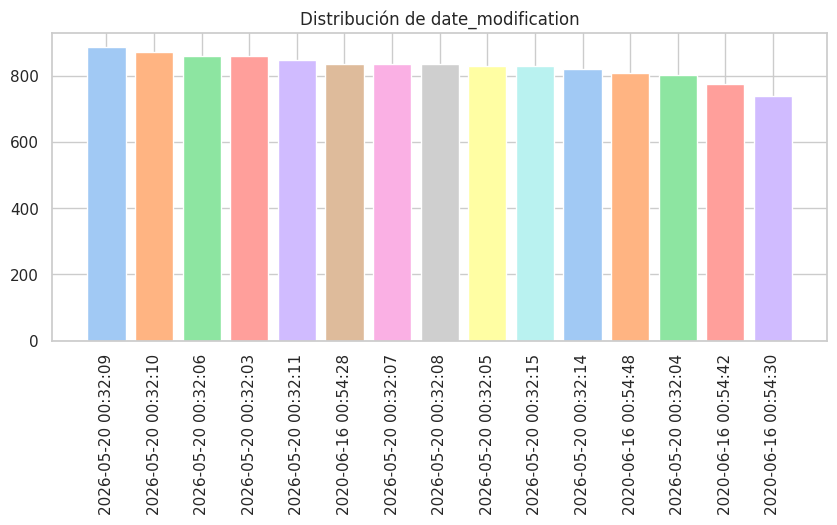

In [16]:
cat_cols = eda.select_dtypes(include="object").columns

for col in cat_cols:

    counts = eda[col].value_counts().head(15)

    plt.figure(figsize=(10,4))

    plt.bar(
        counts.index,
        counts.values,
        color=pastel_colors(len(counts))
    )

    plt.title(f"Distribución de {col}")
    plt.xticks(rotation=90)

    plt.show()

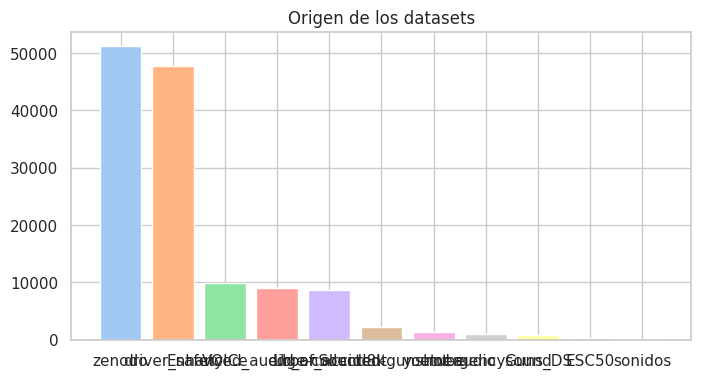

In [17]:
source_counts = eda["dataset_source"].value_counts()

plt.figure(figsize=(8,4))

plt.bar(
    source_counts.index,
    source_counts.values,
    color=pastel_colors(len(source_counts))
)

plt.title("Origen de los datasets")

plt.show()

El análisis por fuente de dataset revela especialización acústica entre repositorios, contribuyendo a diversidad semántica del conjunto final y favoreciendo la capacidad de generalización del modelo.

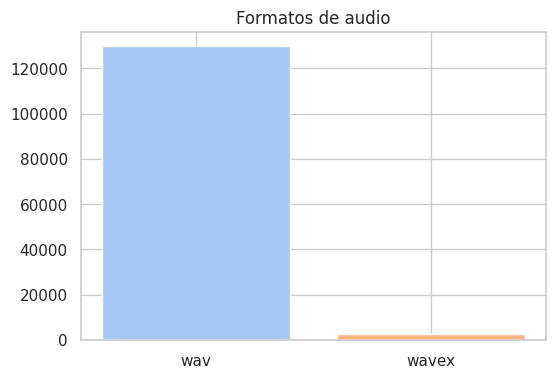

In [18]:
format_counts = eda["audio_format"].value_counts()

plt.figure(figsize=(6,4))

plt.bar(
    format_counts.index,
    format_counts.values,
    color=pastel_colors(len(format_counts))
)

plt.title("Formatos de audio")

plt.show()

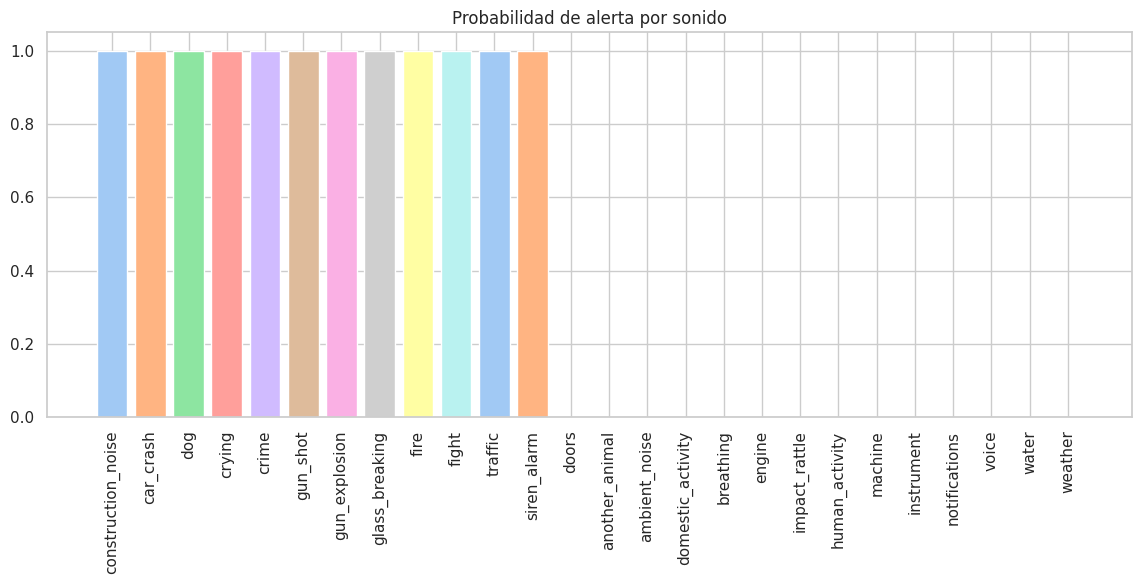

In [19]:
alert_ratio = (
    eda.groupby("human_label")["alertable"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14,5))
plt.bar(
    alert_ratio.index,
    alert_ratio.values,
    color=pastel_colors(len(alert_ratio))
)
plt.xticks(rotation=90)
plt.title("Probabilidad de alerta por sonido")
plt.show()

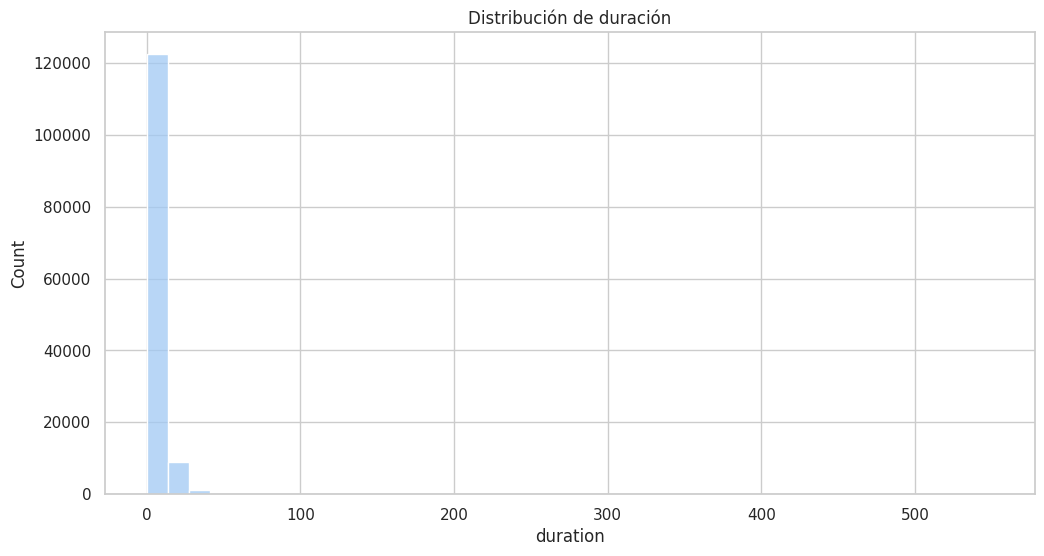

In [20]:
sns.histplot(
    eda["duration"],
    bins=40,
    color=pastel_colors(1)[0]
)
plt.title("Distribución de duración")
plt.show()

In [21]:
numeric_cols = [
    "duration",
    "sample_rate",
    "bit_depth",
    "bit_velocity",
    "size"
]

eda[numeric_cols].describe()

,duration,sample_rate,bit_depth,bit_velocity,size
count,132379.000000,132379.000000,132370.000000,1.323700e+05,132379.000000
mean,4.852201,34012.803337,22.224734,7.240811e+05,430.887647
std,6.947076,14432.114529,7.718821,4.168731e+05,671.946820
min,0.025000,8000.000000,8.000000,8.820000e+04,1.610000
25%,1.294000,16000.000000,16.000000,5.120000e+05,98.270000
50%,3.061000,44100.000000,16.000000,7.056000e+05,227.030000
75%,5.761000,44100.000000,32.000000,7.056000e+05,542.620000
max,550.249000,192000.000000,32.000000,1.228800e+07,62015.670000


/tmp/ipykernel_82102/3640297132.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Axes: xlabel='alertable', ylabel='duration'>

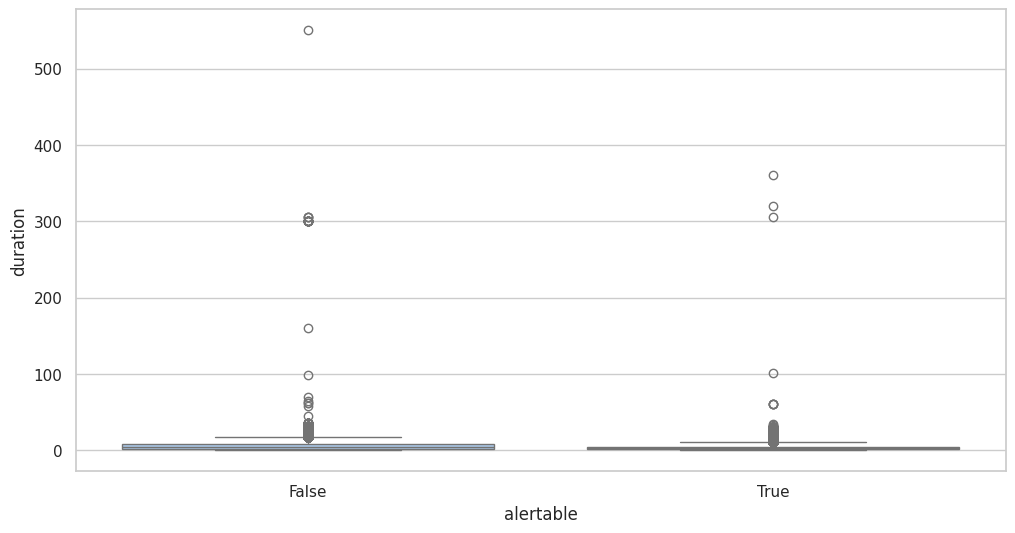

In [22]:
sns.boxplot(
    data=eda,
    x="alertable",
    y="duration",
    palette=pastel_colors(2)
)

La variabilidad en parámetros técnicos del audio confirma heterogeneidad en las condiciones de captura. Esto puede introducir ruido en el aprendizaje y sugiere la necesidad de normalización acústica previa al entrenamiento.

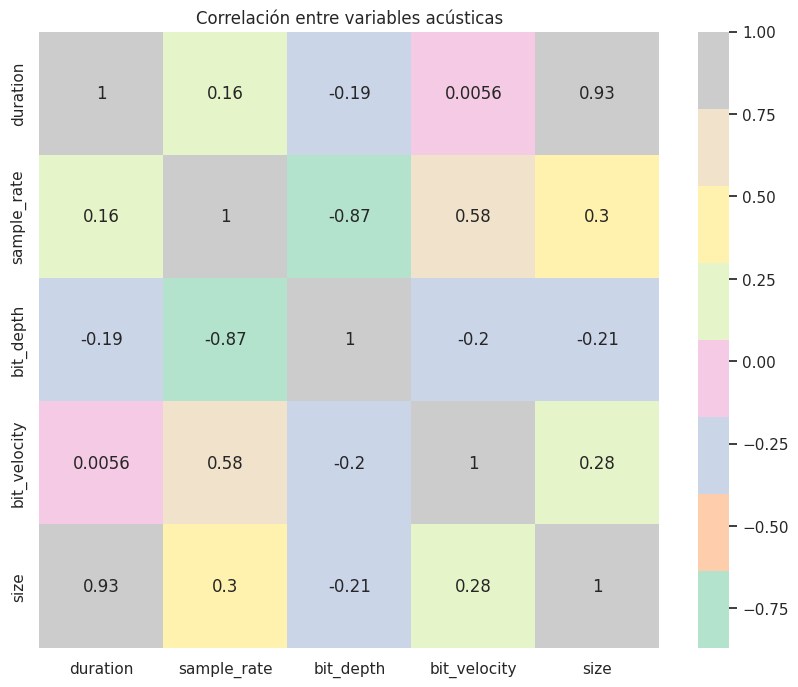

In [23]:
plt.figure(figsize=(10,8))

sns.heatmap(
    eda[numeric_cols].corr(),
    annot=True,
    cmap="Pastel2"
)

plt.title("Correlación entre variables acústicas")
plt.show()

Las correlaciones entre variables numéricas presentan baja asociación con la variable objetivo, sugiriendo que la discriminación entre clases dependerá principalmente de características espectrales del audio y no de metadatos técnicos.

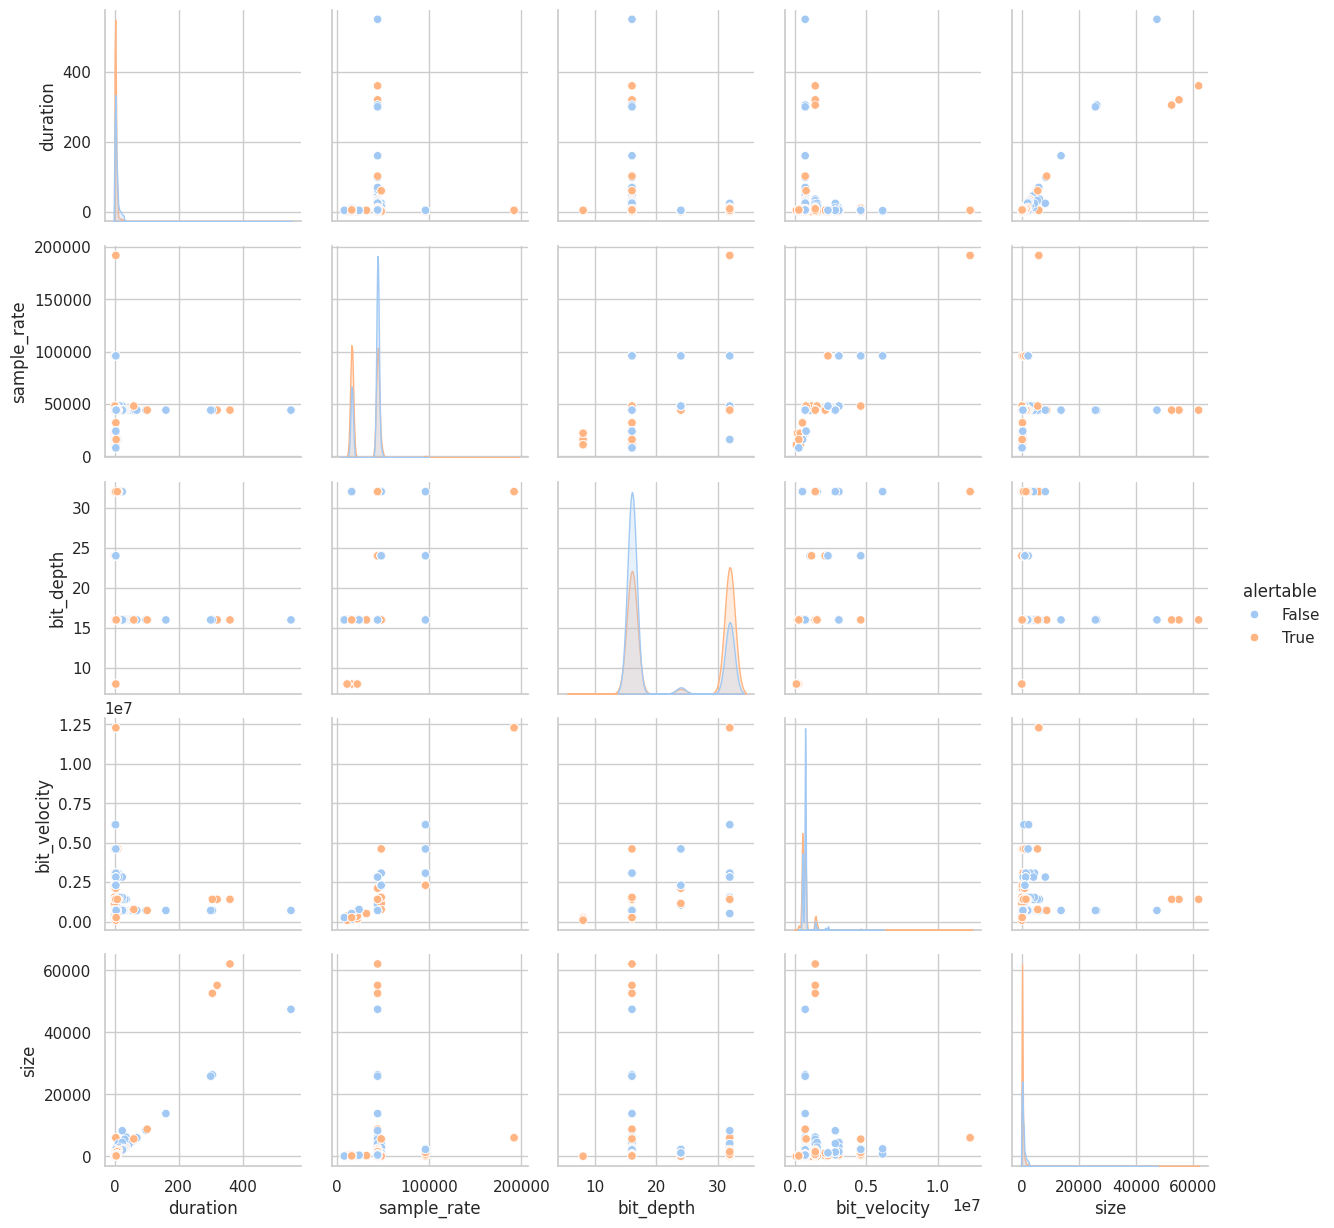

In [24]:
sns.pairplot(
    eda[numeric_cols + ["alertable"]],
    hue="alertable",
    palette="pastel"
)

El análisis multivariado mediante pairplots evidencia ausencia de separación lineal entre clases, validando la necesidad de modelos no lineales basados en representación acústica profunda.

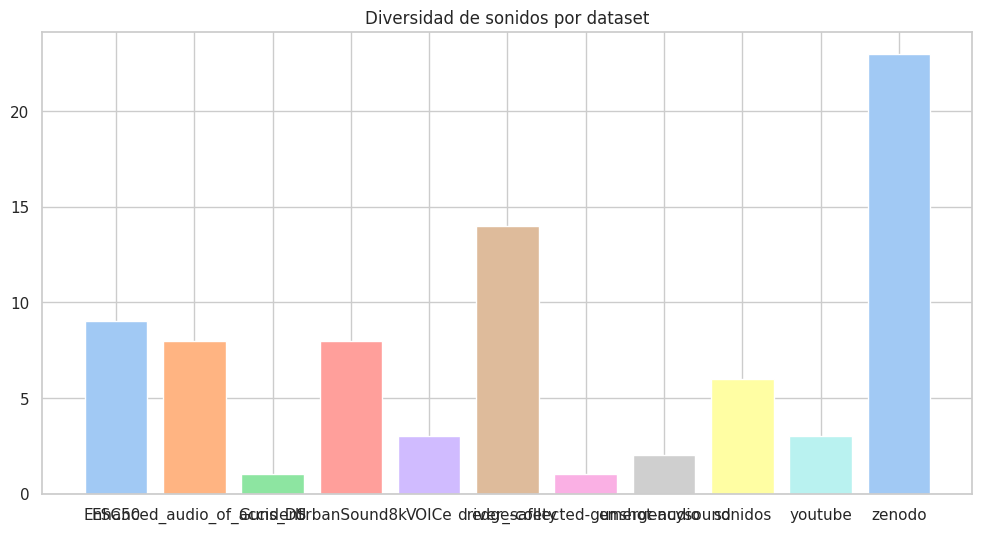

In [25]:
diversidad = eda.groupby("dataset_source")["human_label"].nunique()

plt.bar(
    diversidad.index,
    diversidad.values,
    color=pastel_colors(len(diversidad))
)

plt.title("Diversidad de sonidos por dataset")
plt.show()

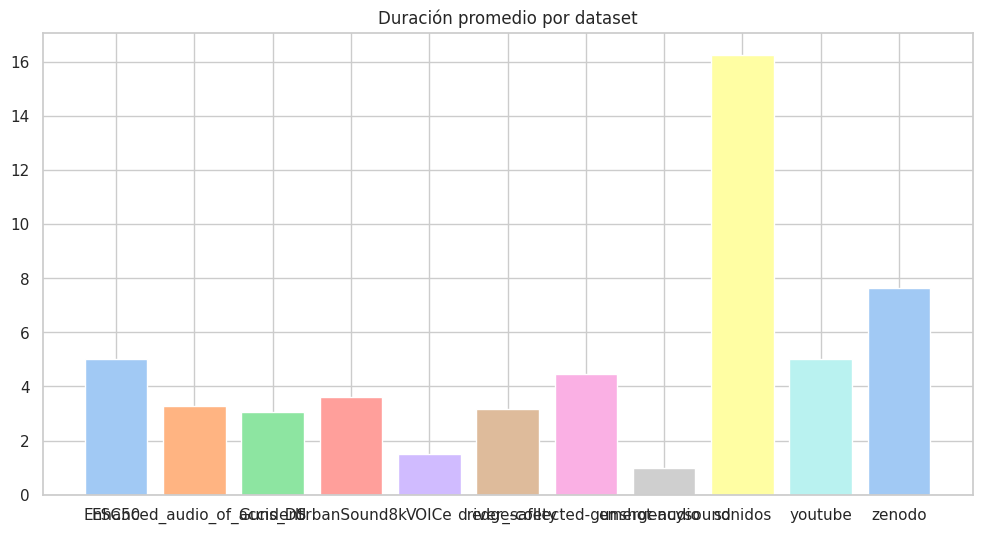

In [26]:
duracion_dataset = eda.groupby("dataset_source")["duration"].mean()

plt.bar(
    duracion_dataset.index,
    duracion_dataset.values,
    color=pastel_colors(len(duracion_dataset))
)

plt.title("Duración promedio por dataset")
plt.show()

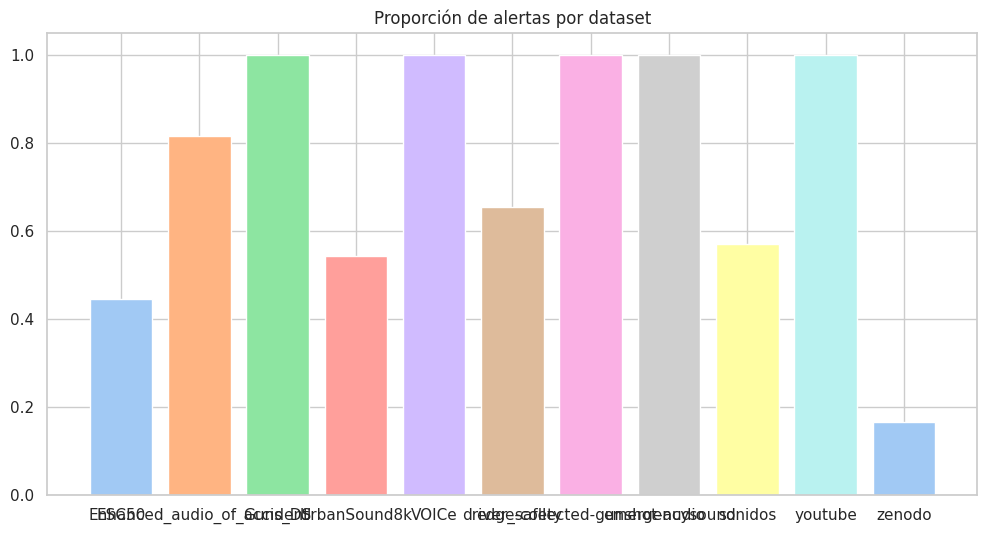

In [27]:
alert_dataset = eda.groupby("dataset_source")["alertable"].mean()

plt.bar(
    alert_dataset.index,
    alert_dataset.values,
    color=pastel_colors(len(alert_dataset))
)

plt.title("Proporción de alertas por dataset")
plt.show()

In [28]:
pd.crosstab(
    eda["env"],
    eda["alertable"],
    normalize="index"
)

alertable,False,True
env,,
exterior,0.121036,0.878964
indefinida,0.277628,0.722372


# Balanceo de clases

In [29]:
alertables = eda[eda["alertable"] == 1]
no_alertables = eda[eda["alertable"] == 0]

print("Alertables:", len(alertables))
print("No alertables:", len(no_alertables))

Alertables: 67122
No alertables: 65262


In [30]:
# tamaños actuales
n_alertables = len(alertables)

# calcular tamaño final del dataset
total_target = int(n_alertables / 0.7)

# cuántas no_alertables necesito (30%)
n_no_alertables_target = int(total_target * 0.3)

print("No alertables necesarias:", n_no_alertables_target)
print("No alertables disponibles:", len(no_alertables))

No alertables necesarias: 28766
No alertables disponibles: 65262


### Undersampling -> clases NO alertables

In [ ]:
no_alertables_under = resample(
    no_alertables,
    replace=False,
    n_samples=n_no_alertables_target,
    random_state=42
)

In [32]:
eda_balanced = pd.concat([alertables, no_alertables_under])

In [33]:
eda_balanced["alertable"].value_counts(normalize=True)

alertable
True     0.700004
False    0.299996
Name: proportion, dtype: float64

<Axes: title={'center': 'Distribución original'}, xlabel='alertable'>

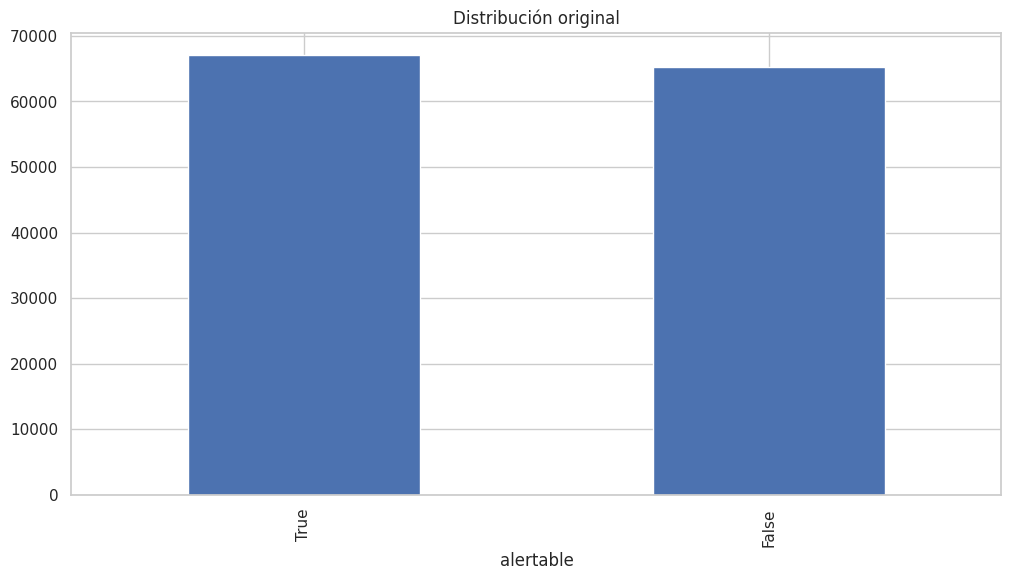

In [34]:
eda["alertable"].value_counts().plot(
    kind="bar",
    title="Distribución original"
)

<Axes: title={'center': 'Distribución balanceada (simulación)'}, xlabel='alertable'>

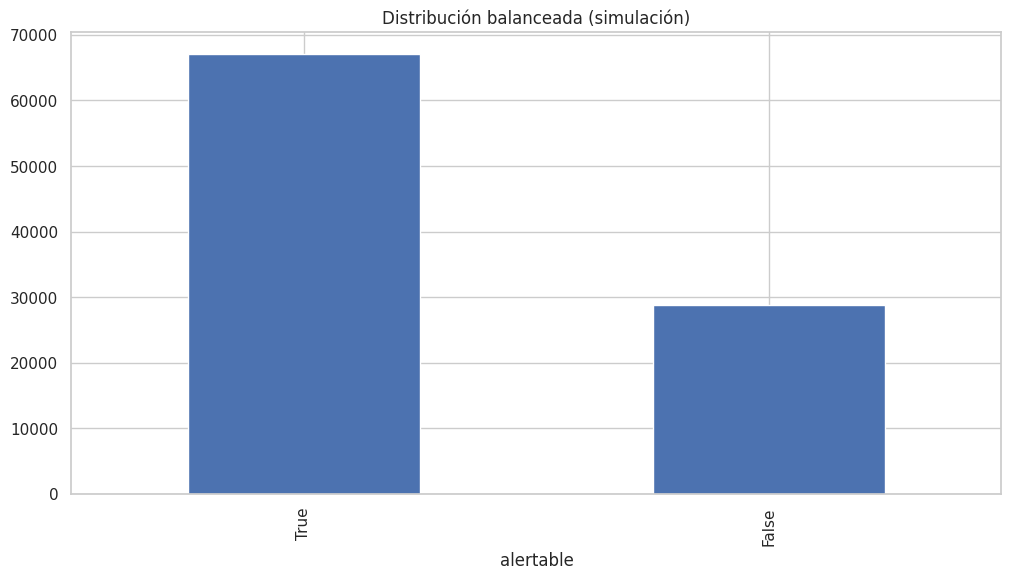

In [35]:
eda_balanced["alertable"].value_counts().plot(
    kind="bar",
    title="Distribución balanceada (simulación)"
)

In [36]:
eda_balanced["human_label"].value_counts()

human_label
traffic               17581
siren_alarm           10023
gun_shot               6616
instrument             6437
crying                 6220
glass_breaking         4811
dog                    4600
fight                  3868
car_crash              3662
construction_noise     3038
voice                  2994
notifications          2853
crime                  2550
gun_explosion          2490
domestic_activity      2478
another_animal         2364
ambient_noise          2074
weather                1859
breathing              1760
human_activity         1724
fire                   1663
water                  1087
impact_rattle          1076
engine                  964
doors                   606
machine                 490
Name: count, dtype: int64

In [37]:
df = eda_balanced.copy()
label_counts = (
    df["human_label"]
    .value_counts()
    .reset_index()
)

label_counts.columns = ["label", "count"]

label_counts.head()

,label,count
0,traffic,17581
1,siren_alarm,10023
2,gun_shot,6616
3,instrument,6437
4,crying,6220


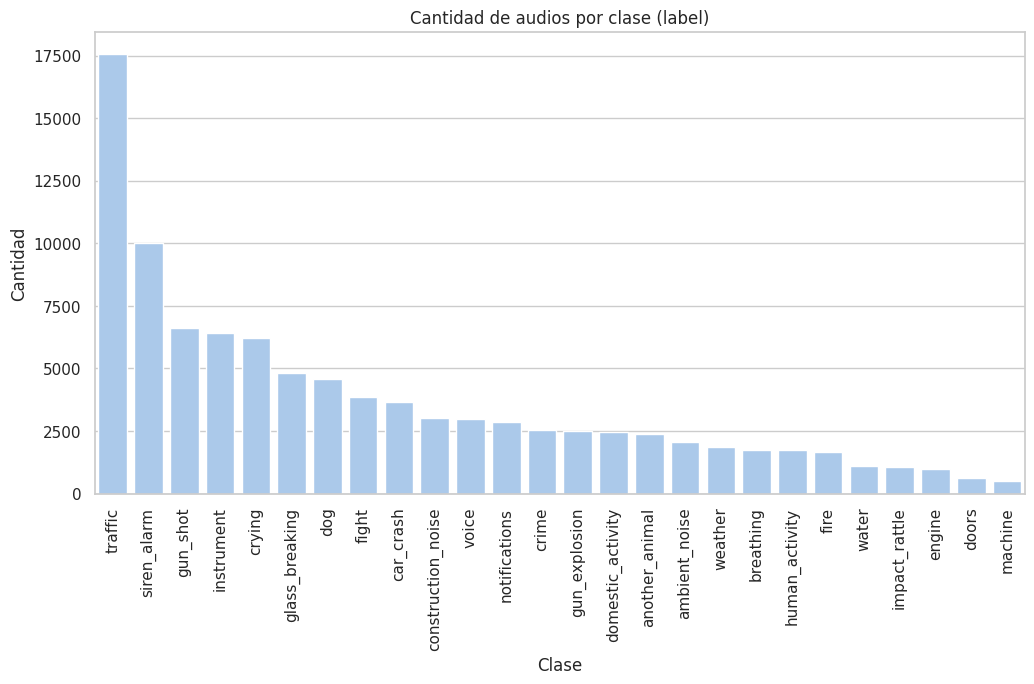

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_palette("pastel")

plt.figure(figsize=(12,6))

sns.barplot(
    data=label_counts,
    x="label",
    y="count"
)

plt.xticks(rotation=90)
plt.title("Cantidad de audios por clase (label)")
plt.xlabel("Clase")
plt.ylabel("Cantidad")

plt.show()

In [39]:
eda_balanced.to_csv("../data/raw/eda_balanced.csv", index=False)